# Mixture Cure Survival Model: Bayesian vs Frequentist

This notebook introduces the **mixture cure model** and compares two implementations on a synthetic customer-returns dataset.

| | Approach | Library |
|---|---|---|
| **Frequentist** | Maximum Likelihood Estimation | `lifelines.MixtureCureFitter` |
| **Bayesian** | MCMC sampling | `bayes_survival.LogLogisticCureModel` (PyMC) |

Both share the same **mixture survival function**:

$$S_{\text{mix}}(t \mid x) = \pi(x) \cdot S_u(t \mid x) + (1 - \pi(x))$$

where:
- $\pi(x)$ — probability of being **susceptible** (will eventually experience the event)
- $S_u(t \mid x)$ — survival function among susceptibles (log-logistic)
- $1 - \pi(x)$ — **cure probability**: the fraction who will never experience the event

As $t \to \infty$, $S_{\text{mix}} \to 1 - \pi(x) > 0$ — the survival curve **plateaus above zero** rather than reaching zero, which is the defining feature of a cure model.

**Dataset**: 1,000 synthetic e-commerce customers — days until product return (or censoring at 30 days), with known true parameters for parameter recovery verification.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm

from lifelines import MixtureCureFitter, LogLogisticFitter, KaplanMeierFitter
from bayes_survival.survival_models.cure import LogLogisticCureModel

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
az.style.use('arviz-white')

## 1. The Synthetic Returns Dataset

We simulate 1,000 customers from an online retailer. Each customer either returns their purchase within 30 days or keeps it permanently. Customers who keep the item are **cured** — they will never return it regardless of how long we wait.

| Column | Description |
|---|---|
| `log_price` | Natural log of item price (£); higher price → less likely to return |
| `category` | Product category: 1 = apparel, 0 = other; apparel → more likely to return |
| `premium` | Customer segment: 1 = premium account, 0 = standard; premium → returns faster |
| `t_obs` | Days from purchase until return, or day 30 if not returned |
| `event` | 1 = return observed, 0 = censored at day 30 |

**True parameters are known** — this lets us check that the model recovers them correctly.

### Two-component data generating process

**Cure sub-model** — who will ever return?
$$\pi(x) = \sigma(\alpha + x_1 \beta_1 + x_2 \beta_2 + x_3 \beta_3)$$

**Timing sub-model** — when do susceptibles return?
$$T \mid \text{susceptible} \sim \text{LogLogistic}(\lambda(x),\; \text{shape})$$
$$\lambda(x) = \exp(\gamma + x \cdot \delta)$$

The log-logistic distribution has a non-monotonic hazard (rises then falls), making it suitable for return behaviour that peaks some days after purchase.

In [2]:
np.random.seed(42)
n, T = 1000, 30

log_price = np.random.normal(4, 0.8, n)        # log(price in £), mean ~ £55
category  = np.random.binomial(1, 0.4, n)      # 1 = apparel (40%)
premium   = np.random.binomial(1, 0.25, n)     # 1 = premium customer (25%)
X = np.column_stack([log_price, category, premium])

# --- Cure sub-model: susceptibility probability --------------------------------
true_alpha = -0.8
true_beta  = np.array([-0.3, 1, 2])       # price (-), apparel (+), premium (+)

pi_true     = stats.logistic.cdf(true_alpha + X @ true_beta)
susceptible = np.random.binomial(1, pi_true)   # 1 = will eventually return

# --- Timing sub-model: log-logistic return times ------------------------------
true_gamma = 1.95
true_delta = np.array([0.2, -0.5, -0.4])      # price (+slower), apparel (-faster), premium (-faster)
true_shape = 3.0                               # shape > 1: unimodal hazard

lam_true = np.exp(true_gamma + X @ true_delta)

# Log-logistic quantile: T = lam * (U / (1-U))^(1/shape) for U ~ Uniform(0,1)
U = np.random.uniform(size=n)
t_latent = lam_true * (U / (1.0 - U)) ** (1.0 / true_shape)

# --- Observed data: right-censored at T = 30 days ----------------------------
t_obs = np.where(susceptible & (t_latent <= T), t_latent, float(T))
event = (susceptible & (t_latent <= T)).astype(float)

df = pd.DataFrame({'t': t_obs, 'event': event,
                   'log_price': log_price, 'category': category, 'premium': premium})

# Average log-logistic scale for plotting
mu_avg = true_gamma + np.mean(log_price) * true_delta[0] \
                    + np.mean(category)  * true_delta[1] \
                    + np.mean(premium)   * true_delta[2]
lam_avg = np.exp(mu_avg)

print(f'Observations        : {n}')
print(f'Events (returns)    : {int(event.sum())} ({event.mean():.1%})')
print(f'Time range          : {t_obs.min():.2f} – {t_obs.max():.0f} days')
print(f'Avg susceptibility  : {pi_true.mean():.1%}  (true π̄ across all customers)')
print()
df[['log_price', 'category', 'premium']].describe().round(3)

Observations        : 1000
Events (returns)    : 265 (26.5%)
Time range          : 0.72 – 30 days
Avg susceptibility  : 28.2%  (true π̄ across all customers)



,log_price,category,premium
count,1000.000,1000.000,1000.000
mean,4.015,0.417,0.241
std,0.783,0.493,0.428
min,1.407,0.000,0.000
25%,3.482,0.000,0.000
50%,4.020,0.000,0.000
75%,4.518,1.000,0.000
max,7.082,1.000,1.000


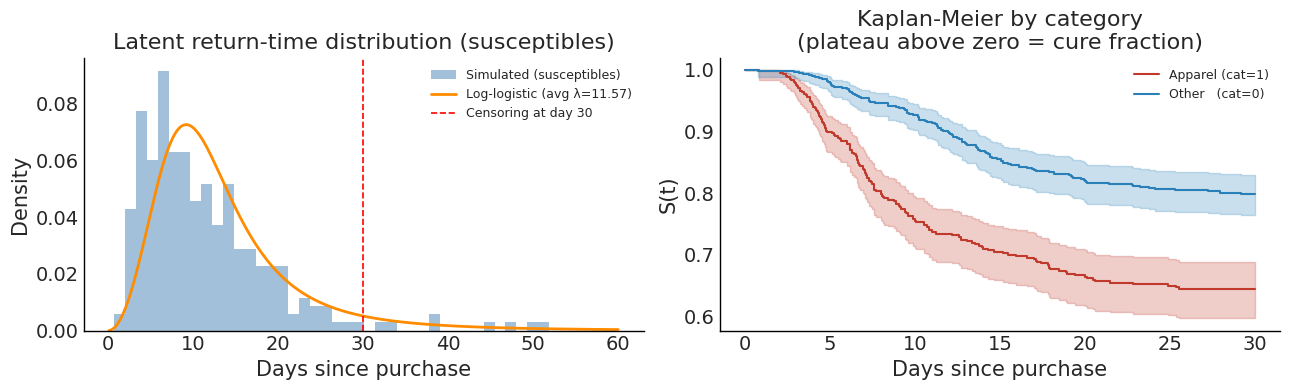

The non-zero long-run plateau in the KM curves is the hallmark of a cure fraction.
Standard survival models (Weibull, log-logistic AFT) cannot reproduce this.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Panel 1: distribution of latent return times for susceptibles ─────────────────
t_susceptible = t_latent[susceptible == 1]
axes[0].hist(t_susceptible[t_susceptible <= 60], bins=40, density=True,
             alpha=0.5, color='steelblue', label='Simulated (susceptibles)')
t_grid = np.linspace(0.1, 60, 400)
# Log-logistic PDF: f(t) = (shape/lam) * (t/lam)^(shape-1) / (1 + (t/lam)^shape)^2
ll_pdf = (true_shape / lam_avg) * (t_grid / lam_avg)**(true_shape - 1) / (1 + (t_grid / lam_avg)**true_shape)**2
axes[0].plot(t_grid, ll_pdf,
             lw=2, color='darkorange', label=f'Log-logistic (avg λ={lam_avg:.2f})')
axes[0].axvline(T, color='red', linestyle='--', lw=1.2, label=f'Censoring at day {T}')
axes[0].set(title='Latent return-time distribution (susceptibles)',
            xlabel='Days since purchase', ylabel='Density')
axes[0].legend(fontsize=9)

# ── Panel 2: KM curves by category — non-zero plateau reveals cure fraction ───
for cat_val, label, color in [(1, 'Apparel (cat=1)', '#c0392b'),
                               (0, 'Other   (cat=0)', '#2980b9')]:
    mask = (category == cat_val)
    kmf = KaplanMeierFitter()
    kmf.fit(t_obs[mask], event[mask], label=label)
    kmf.plot_survival_function(ax=axes[1], ci_show=True, color=color)

axes[1].set(title='Kaplan-Meier by category\n(plateau above zero = cure fraction)',
            xlabel='Days since purchase', ylabel='S(t)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('The non-zero long-run plateau in the KM curves is the hallmark of a cure fraction.\n'
      'Standard survival models (Weibull, log-logistic AFT) cannot reproduce this.')

## 2. Frequentist Baseline: `lifelines.MixtureCureFitter`

lifelines provides `MixtureCureFitter`, a univariate mixture cure model that estimates:
$$S(t) = c + (1 - c)\, S_b(t)$$

where $c$ is a **scalar cure fraction** — a single constant shared across all subjects — and $S_b(t)$ is a parametric baseline survival function (here, log-logistic).

### Key limitation: no covariate-dependent cure probability

`MixtureCureFitter` is a **univariate model**: it estimates one $c$ for the entire population. It cannot learn that apparel customers have a higher return rate than non-apparel customers at the same price. Every subject receives the same cure probability estimate.

The Bayesian `LogLogisticCureModel` replaces the scalar $c$ with a **logistic regression sub-model** that makes the cure probability a function of covariates:
$$\pi(x) = \sigma(\alpha + x \cdot \beta_{\text{cure}})$$
so each customer gets their own susceptibility estimate.

In [4]:
ll_cure = MixtureCureFitter(base_fitter=LogLogisticFitter())
ll_cure.fit(df['t'], event_observed=df['event'])
ll_cure.print_summary()

ll_cured_fraction = ll_cure.cured_fraction_
print(f'\nFitted cure fraction : {ll_cured_fraction:.3f}  (= 1 – π̄, scalar for all customers)')

<lifelines.MixtureCureFitter:"MixtureCure_estimate", fitted with 1000 total observations, 735 right-censored observations>
   number of observations = 1000
number of events observed = 265
           log-likelihood = -1397.49
               hypothesis = cured_fraction_ != 0, alpha_ != 1, beta_ != 1

---
                 coef  se(coef)  coef lower 95%  coef upper 95%
cured_fraction_  0.72      0.02            0.69            0.75
alpha_           9.61      0.47            8.70           10.53
beta_            2.45      0.16            2.14            2.76

                 cmp to     z      p  -log2(p)
cured_fraction_    0.00 46.88 <0.005       inf
alpha_             1.00 18.40 <0.005    248.65
beta_              1.00  9.30 <0.005     65.96
---
AIC = 2800.99


Fitted cure fraction : 0.719  (= 1 – π̄, scalar for all customers)


## 3. Bayesian Mixture Cure Model

`LogLogisticCureModel` uses PyMC for MCMC sampling. Two sub-models are estimated jointly on the same data.

**Cure sub-model** — who will ever return?
$$\pi(x) = \sigma(\alpha + x \cdot \beta_{\text{cure}})$$

**Timing sub-model** — when do susceptibles return?
$$T \mid \text{susceptible} \sim \text{LogLogistic}(\lambda(x),\; \text{shape})$$
$$\lambda(x) = \exp(\gamma + x \cdot \delta)$$

**Default priors:**

| Parameter | Prior | Role |
|---|---|---|
| $\alpha$ | $\mathcal{N}(0, 1)$ | Cure sub-model intercept |
| $\beta_{\text{cure}}$ | $\mathcal{N}(0, 3)$ | Cure sub-model covariate effects |
| $\gamma$ | $\mathcal{N}(0, 1)$ | Timing sub-model intercept |
| $\delta$ | $\mathcal{N}(0, 2)$ | Timing sub-model covariate effects |
| $\text{shape}$ | $\text{Gamma}(5, 2)$ | Log-logistic shape parameter |

All priors are weakly regularising — they are wide enough not to dominate the likelihood with 1,000 observations.

An intercept is included in each sub-model automatically — pass raw covariates only.

In [5]:
X_fit = df[['log_price', 'category', 'premium']].values

bayes_cure = LogLogisticCureModel()
bayes_cure.fit(X_fit, t_obs, event,
               draws=1000, tune=1000, chains=4, random_seed=42)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.42,15
,2000,0,0.35,15
,2000,0,0.34,7
,2000,0,0.39,7


In [6]:
# Posterior summary
az.summary(bayes_cure.idata,
           var_names=['alpha', 'beta_cure', 'gamma', 'delta', 'shape'],
           hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.858,0.398,-1.653,-0.112,0.011,0.007,1245.0,1910.0,1.0
beta_cure[0],-0.300,0.102,-0.502,-0.111,0.003,0.002,1259.0,1891.0,1.0
beta_cure[1],0.983,0.174,0.651,1.318,0.003,0.003,4794.0,3006.0,1.0
beta_cure[2],2.170,0.184,1.819,2.537,0.003,0.003,5345.0,2982.0,1.0
gamma,1.940,0.212,1.504,2.340,0.006,0.004,1251.0,1697.0,1.0
delta[0],0.208,0.053,0.108,0.321,0.001,0.001,1303.0,1757.0,1.0
delta[1],-0.527,0.081,-0.694,-0.376,0.001,0.001,4769.0,3087.0,1.0
delta[2],-0.439,0.081,-0.599,-0.288,0.001,0.001,5045.0,3217.0,1.0
shape,2.841,0.180,2.495,3.182,0.002,0.003,6074.0,3105.0,1.0


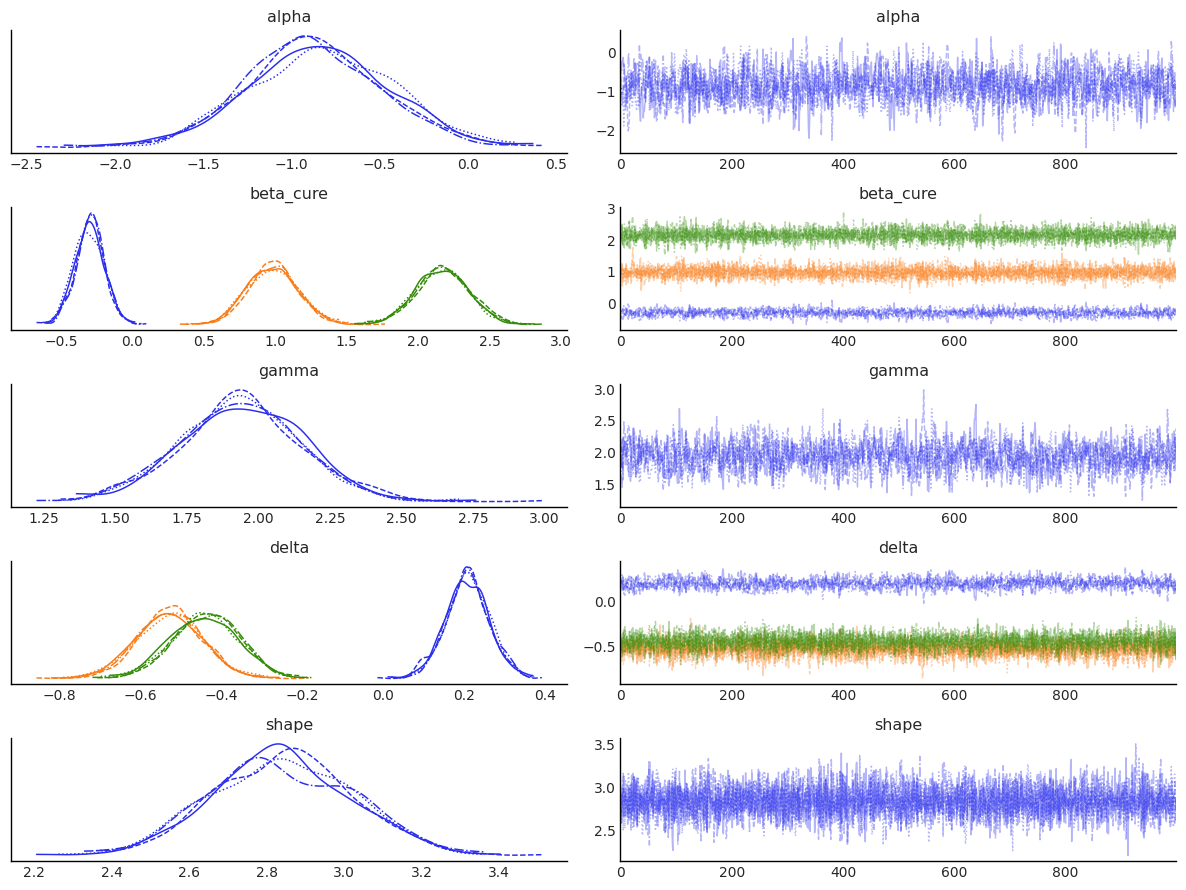

In [7]:
az.plot_trace(bayes_cure.idata,
              var_names=['alpha', 'beta_cure', 'gamma', 'delta', 'shape'],
              compact=True, figsize=(12, 9))
plt.tight_layout()
plt.show()

## 4. Parameter Recovery

Since the data were simulated with known true parameters, we can verify that the posterior credible intervals bracket the true values. This validates the model implementation.

Note that lifelines only estimates one scalar $c$ for everyone — there are no lifelines equivalents for $\alpha$, $\beta_{\text{cure}}$, $\delta$, or shape.

In [8]:
posterior = bayes_cure.idata.posterior
bayes_sum = az.summary(bayes_cure.idata,
                        var_names=['alpha', 'beta_cure', 'gamma', 'delta', 'shape'],
                        hdi_prob=0.95)

true_values = {
    'alpha':          true_alpha,
    'beta_cure[0]':   true_beta[0],
    'beta_cure[1]':   true_beta[1],
    'beta_cure[2]':   true_beta[2],
    'gamma':          true_gamma,
    'delta[0]':       true_delta[0],
    'delta[1]':       true_delta[1],
    'delta[2]':       true_delta[2],
    'shape':          true_shape,
}

param_labels = [
    ('alpha',        r'$\alpha$ — cure intercept',       'Cure'),
    ('beta_cure[0]', r'$\beta_0$ — log-price (cure)',    'Cure'),
    ('beta_cure[1]', r'$\beta_1$ — apparel (cure)',      'Cure'),
    ('beta_cure[2]', r'$\beta_2$ — premium (cure)',      'Cure'),
    ('gamma',        r'$\gamma$ — timing intercept',     'Timing'),
    ('delta[0]',     r'$\delta_0$ — log-price (timing)', 'Timing'),
    ('delta[1]',     r'$\delta_1$ — apparel (timing)',   'Timing'),
    ('delta[2]',     r'$\delta_2$ — premium (timing)',   'Timing'),
    ('shape',        r'shape — log-logistic shape',      'Timing'),
]

rows = []
for key, label, submodel in param_labels:
    lo = bayes_sum.loc[key, 'hdi_2.5%']
    hi = bayes_sum.loc[key, 'hdi_97.5%']
    tv = true_values[key]
    rows.append({
        'Sub-model':    submodel,
        'Parameter':    label,
        'True value':   round(tv, 2),
        'Bayes mean':   round(bayes_sum.loc[key, 'mean'], 3),
        'Bayes 95% HDI': f'[{lo:.3f}, {hi:.3f}]',
        'Covers true?': '✓' if lo <= tv <= hi else '✗',
    })

pd.DataFrame(rows).set_index(['Sub-model', 'Parameter'])

True value  Bayes mean  \
Sub-model Parameter                                                 
Cure      $\alpha$ — cure intercept             -0.80      -0.858   
          $\beta_0$ — log-price (cure)          -0.30      -0.300   
          $\beta_1$ — apparel (cure)             1.00       0.983   
          $\beta_2$ — premium (cure)             2.00       2.170   
Timing    $\gamma$ — timing intercept            1.95       1.940   
          $\delta_0$ — log-price (timing)        0.20       0.208   
          $\delta_1$ — apparel (timing)         -0.50      -0.527   
          $\delta_2$ — premium (timing)         -0.40      -0.439   
          shape — log-logistic shape             3.00       2.841   

                                              Bayes 95% HDI Covers true?  
Sub-model Parameter                                                       
Cure      $\alpha$ — cure intercept        [-1.653, -0.112]            ✓  
          $\beta_0$ — log-price (cure)     [-0.502, -0.111]            ✓  
          $\beta_1$ — apparel (cure)         [0.651, 1.318]            ✓  
          $\beta_2$ — premium (cure)         [1.819, 2.537]            ✓  
Timing    $\gamma$ — timing intercept        [1.504, 2.340]            ✓  
          $\delta_0$ — log-price (timing)    [0.108, 0.321]            ✓  
          $\delta_1$ — apparel (timing)    [-0.694, -0.376]            ✓  
          $\delta_2$ — premium (timing)    [-0.599, -0.288]            ✓  
          shape — log-logistic shape         [2.495, 3.182]            ✓

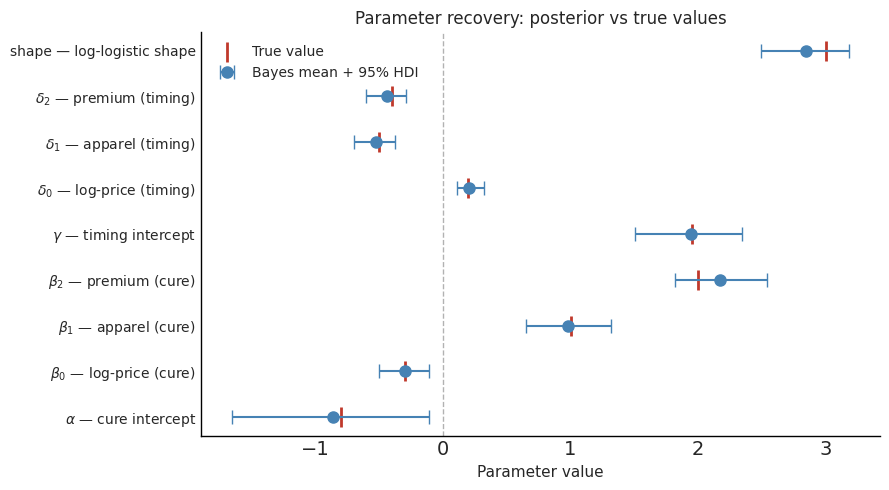

In [9]:
# â”€â”€ Forest plot: posterior means + HDI vs true values â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, ax = plt.subplots(figsize=(9, 5))

y_pos = np.arange(len(param_labels))
for i, (key, label, _) in enumerate(param_labels):
    mean = bayes_sum.loc[key, 'mean']
    lo   = bayes_sum.loc[key, 'hdi_2.5%']
    hi   = bayes_sum.loc[key, 'hdi_97.5%']
    ax.errorbar(mean, y_pos[i],
                xerr=[[mean - lo], [hi - mean]],
                fmt='o', color='steelblue', ms=8, capsize=5, lw=1.5,
                label='Bayes mean + 95% HDI' if i == 0 else '')
    ax.scatter(true_values[key], y_pos[i],
               marker='|', s=200, color='#c0392b', lw=2,
               label='True value' if i == 0 else '')

ax.axvline(0, color='grey', linestyle='--', lw=1, alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels([lbl for _, lbl, _ in param_labels], fontsize=10)
ax.set_xlabel('Parameter value', fontsize=11)
ax.set_title('Parameter recovery: posterior vs true values', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 5. Survival Function Comparison

We compare predicted survival curves for three representative customer profiles.

| Profile | log_price | category | premium | Expected behaviour |
|---|---|---|---|---|
| Apparel, low price | 3.0 (~Â£20) | 1 | 0 | High return rate, fast |
| Non-apparel, high price | 5.0 (~Â£148) | 0 | 0 | Low return rate, slow |
| Apparel, premium | 4.0 (~Â£55) | 1 | 1 | High return rate, very fast |

**Note**: The lifelines model is univariate â€” it returns the **same curve for every profile** because it cannot model covariate effects. The Bayesian model produces distinct curves with profile-specific asymptotes (cure fractions).

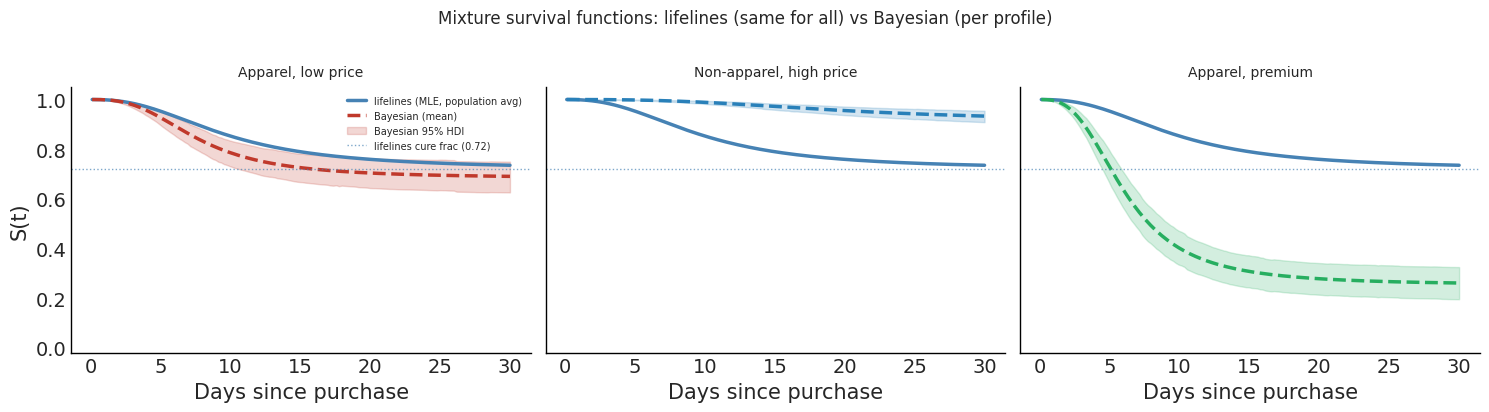

In [10]:
profiles = {
    'Apparel, low price':      np.array([[3.0, 1.0, 0.0]]),
    'Non-apparel, high price': np.array([[5.0, 0.0, 0.0]]),
    'Apparel, premium':        np.array([[4.0, 1.0, 1.0]]),
}
eval_times = np.linspace(0.1, T, 150)

# lifelines: one curve for everyone (no covariates)
ll_surv = ll_cure.survival_function_at_times(eval_times).values

# Bayesian: one curve per profile
bayes_preds = {
    label: bayes_cure.predict_survival_function(X=x, times=eval_times, hdi_prob=0.95)
    for label, x in profiles.items()
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = ['#c0392b', '#2980b9', '#27ae60']

for ax, (label, x), color in zip(axes, profiles.items(), colors):
    pred = bayes_preds[label]

    # lifelines â€” single population-average curve (same in every panel)
    ax.plot(eval_times, ll_surv,
            color='steelblue', lw=2.5, label='lifelines (MLE, population avg)')

    # Bayesian â€” profile-specific mean + HDI
    ax.plot(eval_times, pred.mean[0],
            color=color, lw=2.5, ls='--', label='Bayesian (mean)')
    ax.fill_between(eval_times, pred.hdi_lower[0], pred.hdi_upper[0],
                    color=color, alpha=0.2, label='Bayesian 95% HDI')

    ax.axhline(ll_cured_fraction, color='steelblue', lw=1, ls=':', alpha=0.7,
               label=f'lifelines cure frac ({ll_cured_fraction:.2f})')

    ax.set_title(label, fontsize=10, pad=8)
    ax.set_xlabel('Days since purchase')
    ax.set_ylim(-0.02, 1.05)
    if ax is axes[0]:
        ax.set_ylabel('S(t)')
        ax.legend(fontsize=7)

plt.suptitle('Mixture survival functions: lifelines (same for all) vs Bayesian (per profile)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 6. Covariate-Dependent Cure Probability

The Bayesian model's key advantage over `MixtureCureFitter` is that it learns how the cure fraction varies with covariates. The plot below shows $P(\text{cured} \mid x) = 1 - \pi(x)$ as a function of item price, separately for apparel and non-apparel customers.

The lifelines estimate (horizontal line) shows only the population average â€” it is blind to these differences.

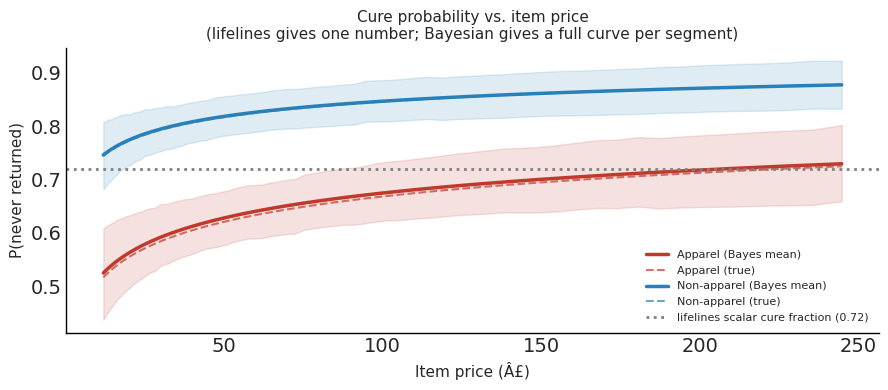

In [11]:
log_prices = np.linspace(2.5, 5.5, 80)

# Average premium rate across dataset
avg_premium = premium.mean()
X_apparel  = np.column_stack([log_prices, np.ones(80),  np.full(80, avg_premium)])
X_other    = np.column_stack([log_prices, np.zeros(80), np.full(80, avg_premium)])

cp_apparel = bayes_cure.predict_cure_probability(X_apparel)
cp_other   = bayes_cure.predict_cure_probability(X_other)

# True cure probabilities
true_cp_apparel = 1 - stats.logistic.cdf(true_alpha + log_prices * true_beta[0]
                                         + 1 * true_beta[1] + avg_premium * true_beta[2])
true_cp_other   = 1 - stats.logistic.cdf(true_alpha + log_prices * true_beta[0]
                                         + 0 * true_beta[1] + avg_premium * true_beta[2])

fig, ax = plt.subplots(figsize=(9, 4))
for cp, true_cp, label, color in [
    (cp_apparel, true_cp_apparel, 'Apparel',     '#c0392b'),
    (cp_other,   true_cp_other,   'Non-apparel', '#2980b9'),
]:
    ax.plot(np.exp(log_prices), cp.mean, color=color, lw=2.5, label=f'{label} (Bayes mean)')
    ax.fill_between(np.exp(log_prices), cp.hdi_lower, cp.hdi_upper,
                    color=color, alpha=0.15)
    ax.plot(np.exp(log_prices), true_cp, color=color, lw=1.5, ls='--', alpha=0.7,
            label=f'{label} (true)')

ax.axhline(ll_cured_fraction, color='grey', lw=2, ls=':',
           label=f'lifelines scalar cure fraction ({ll_cured_fraction:.2f})')

ax.set_xlabel('Item price (Â£)', fontsize=11)
ax.set_ylabel('P(never returned)', fontsize=11)
ax.set_title('Cure probability vs. item price\n'
             '(lifelines gives one number; Bayesian gives a full curve per segment)',
             fontsize=11)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Why `pm.Potential` instead of `pm.Censored`

In the standard AFT models (`WeibullAFTModel`, `LogLogisticAFTModel`), censoring is handled by `pm.Censored`. That works because the censored likelihood factorises cleanly over a **single distribution**:

$$\ell(\theta \mid t, \delta) = \begin{cases} f(t \mid \theta) & \delta = 1 \text{ (event)} \\ S(t \mid \theta) & \delta = 0 \text{ (censored)} \end{cases}$$

`pm.Censored` wraps one PyMC distribution and routes each observation to `logp` (event) or `logcdf` (censored) automatically, depending on whether the upper bound is finite.

---

In the **mixture cure model**, the censored contribution is **not** the survival function of a single distribution. A censored observation could be censored for two different reasons:

1. The customer is **susceptible** but their return time exceeds the censoring horizon — probability $\pi(x) \cdot S_u(t \mid x)$
2. The customer is **cured** and will never return — probability $1 - \pi(x)$

We cannot tell these apart, so the censored likelihood is their sum:

$$\ell(\theta \mid t, \delta=0) = \pi(x) \cdot S_u(t \mid x) + (1 - \pi(x))$$

This is a **weighted mixture of two terms** from two separate model components. `pm.Censored` has no mechanism to express this.

`pm.Potential` lets us inject an **arbitrary log-likelihood** contribution per observation:

```python
pm.Potential(
    "obs",
    pt.switch(
        pt.eq(event, 1.0),
        pt.log(pi) + log_f,                       # event: log pi + log f(t)
        pt.log(pi * S_u + (1.0 - pi)),            # censored: log mixture
    )
)
```

This is the exact log-likelihood for the mixture cure model, and it cannot be expressed through `pm.Censored`.

## Summary

| Aspect | `lifelines.MixtureCureFitter` | `bayes_survival.LogLogisticCureModel` |
|---|---|---|
| Cure fraction | **Scalar constant** — same for every subject | **Logistic regression** — per-covariate |
| Timing distribution | Configurable (here: log-logistic) | Log-logistic |
| Covariate effects on cure | **None** | Full regression (β_cure) |
| Covariate effects on timing | **None** | Full regression (δ) |
| Uncertainty quantification | Asymptotic 95% CI | Exact 95% HDI (MCMC) |
| Priors | None | Normal / Gamma (regularising) |
| Compute time | Seconds | ~60–90 seconds (MCMC) |
| Parameter recovery | Not applicable | All 9 parameters |

**Key observations from this dataset:**

- **Parameter recovery**: All true parameters should be covered by their 95% HDI, validating the implementation.
- **Covariate heterogeneity**: Apparel customers have a substantially lower cure probability than non-apparel customers at the same price — a pattern lifelines cannot capture with a scalar cure fraction.
- **Survival asymptotes**: The Bayesian survival curves plateau at different levels per profile, correctly reflecting profile-specific cure fractions.
- **Likelihood design**: The mixture structure requires `pm.Potential` rather than `pm.Censored` because the censored contribution involves two additive terms from separate model components.